In [80]:
# References for NASA promise dataset repository
#https://www.kaggle.com/datasets/aczy156/software-defect-prediction-nasa?select=jm1.csv
#https://www.se.rit.edu/~swen-789/projects/p1.html
#https://github.com/ApoorvaKrisna/NASA-promise-dataset-repository

In [78]:
import numpy as np
import pandas as pd
import networkx as nx
import dowhy
from dowhy.utils.plotting import plot
import matplotlib.pyplot as plt
import networkx as nx

import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

import dowhy.gcm as gcm
from dowhy.gcm import StructuralCausalModel
from dowhy.gcm import AdditiveNoiseModel, EmpiricalDistribution
from dowhy.gcm.ml import (
    create_linear_regressor,
    create_logistic_regression_classifier
)
from dowhy.utils import bar_plot

# Show all columns regardless of how many there are
pd.set_option('display.max_columns', None)
# Increase the width of the display area
pd.set_option('display.width', 2000)
# Optional: suppress scientific notation for clearer causal weights
pd.set_option('display.float_format', lambda x: '%.4f' % x)

def display_df(df):
  styled_df = df.style.format("{:.3f}").set_table_styles([
    {'selector': 'th', 'props': [('white-space', 'nowrap')]},
    {'selector': 'td', 'props': [('white-space', 'nowrap')]}
  ])

  display(styled_df)

In [32]:
############################################################################################################################################
# Data preprocessing before causal inference
############################################################################################################################################

target = "Defect"

col_names_df = pd.read_csv("nasa_kaggle_col_mapping.csv")
col_name_dict = dict(zip(col_names_df["original"].values, col_names_df["short_name"].values))

df = pd.read_csv("cm1.csv").rename(columns=col_name_dict)

#display_df(df.head(2))
df["Defect"] = df["Defect"]*1
display_df(df.head(2))

print("Number of defects and shape: ",df["Defect"].sum(), '{:,.0f}'.format(len(df["Defect"])))
print("Ratio of defects", '{:,.2f}'.format(100 * df["Defect"].sum()/len(df["Defect"]))+' %')

# Drop identifier
if "id" in df.columns:
    df = df.drop(columns=["id"])

df["Defect"] = df["Defect"].fillna(0) # Target
df["Size"] = df[["CodeLOC","HalLOC","ComLOC"]].mean(axis=1)
df["McCabe"] = df[["CycComp","EssComp","DesComp"]].mean(axis=1)
df["HalStruct"] = df[["UniqOp","UniqOpr"]].mean(axis=1)
df["HalCog"] = df[["HalDiff","HalEff"]].mean(axis=1)

df = df[["Size","McCabe","HalStruct","HalCog","Defect"]]

print(df.columns)

,id,CodeLOC,CycComp,EssComp,DesComp,HalTok,HalVol,HalLen,HalDiff,HalIntel,HalEff,HalTime,t,HalLOC,ComLOC,BlankLOC,locCodeAndComment,UniqOp,UniqOpr,TotOp,TotOpr,Branches,Defect
0,1.000,1.100,1.400,1.400,1.400,1.300,1.300,1.300,1.300,1.300,1.300,1.300,1.300,2.000,2.000,2.000,2.000,1.200,1.200,1.200,1.200,1.400,0.000
1,2.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


Number of defects and shape:  49 498
Ratio of defects 9.84 %
Index(['Size', 'McCabe', 'HalStruct', 'HalCog', 'Defect'], dtype='object')


In [33]:
###########################################################################################################################################
# Definitions
# 1. McCabe (Cyclomatic Complexity): Measures the number of independent execution paths in a program’s control flow; higher values indicate
# more branching and structural complexity.
#
# 2. HalStruct (Halstead Structural metric): A Halstead-derived measure capturing structural properties of code based on counts of operators
# and operands, reflecting program size and organization.
#
# 3. HalCog (Halstead Cognitive metric): A Halstead-based metric intended to estimate the cognitive effort required to understand the code,
# derived from operator/operand vocabulary and volume.
#
# NASA JM1: Real flight software, modular C code, defects labeled per module
#
# Static metrics extracted post-hoc: Size is upstream (code written), structural metrics derive from code and 
# defects arise from structural + branching complexity
###########################################################################################################################################

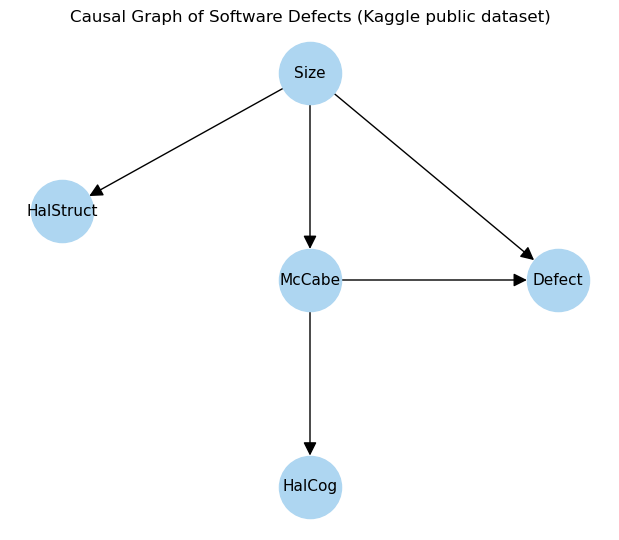

In [71]:
############################################################################################################################################
# Step 1: Model causal graph
############################################################################################################################################

# Create graph
causal_graph = nx.DiGraph()

# Add edges
causal_graph.add_edges_from([
    ("Size", "HalStruct"),
    ("Size", "McCabe"),
    ("Size", "Defect"),
    ("McCabe", "Defect"),
    ("McCabe", "HalCog")
])

# Manual positions to match your sketch
pos = {
    "HalStruct": (-2, 1),
    "Size": (0, 2),
    "McCabe": (0, 0.5),
    "Defect": (2, 0.5),
    "HalCog": (0, -1)
}

# Draw
plt.figure(figsize=(6, 5))
nx.draw(
    causal_graph,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="#AED6F1",
    font_size=11,
    arrowsize=20
)

plt.title("Causal Graph of Software Defects (Kaggle public dataset)")
plt.axis("off")
plt.show()

In [35]:
############################################################################################################################################
# Step 2: Identify
############################################################################################################################################

treatment = "McCabe"

model = dowhy.CausalModel(data=df,
                     graph=causal_graph,
                     treatment=treatment,
                     outcome=target)

identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                    
─────────(E[Defect|Size])
d[McCabe]                
Estimand assumption 1, Unconfoundedness: If U→{McCabe} and U→Defect then P(Defect|McCabe,Size,U) = P(Defect|McCabe,Size)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
    d                    
─────────(E[Defect|Size])
d[McCabe]                
Estimand assumption 1, Unconfoundedness: If U→{McCabe} and U→Defect then P(Defect|McCabe,Size,U) = P(Defect|McCabe,Size)



<span style="font-size:24px; font-weight:bold;">
Estimation and Refutation. Exploratory Data Analysis to Check Results
</span>

In [63]:
############################################################################################################################################
# Step 3: Estimate for McCable, with size as confounder
############################################################################################################################################

model = dowhy.CausalModel(
    data=df,
    treatment=treatment,
    outcome=target,
    common_causes=["Size"]  # adjust for Size
)
identified_estimand = model.identify_effect()

estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.generalized_linear_model",
    method_params={
        "glm_family": sm.families.Binomial()
    }
)

print(estimate)

#What the Refutation p-value Tests. It tests if the refuted estimate statistically different from the original estimate?
#Large p-value (e.g. 0.41). Means: We fail to reject the null. The estimate did NOT significantly change.
#This is a good outcome and suggests that the estimate is robust to that perturbation.

refute = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
print(refute)

# With placebo and permutating the treatment feature

refute = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)

print(refute)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                    
─────────(E[Defect|Size])
d[McCabe]                
Estimand assumption 1, Unconfoundedness: If U→{McCabe} and U→Defect then P(Defect|McCabe,Size,U) = P(Defect|McCabe,Size)

## Realized estimand
b: Defect~Sigmoid(McCabe+Size)
Target units: ate

## Estimate
Mean value: -0.027700329122135825

Refute: Add a random common cause
Estimated effect:-0.027700329122135825
New effect:-0.027734176332188526
p value:0.94

Refute: Use a Placebo Treatment
Estimated effect:-0.027700329122135825
New effect:-0.0010764721809653046
p value:0.98



In [64]:
############################################################################################################################################
# Step 3: Estimate for size standardized, no confounders
############################################################################################################################################
df["Size_std"] = StandardScaler().fit_transform(df[["Size"]])

model = dowhy.CausalModel(
    data=df,
    treatment='Size_std',
    outcome=target,
    #common_causes=["Size"]  # adjust for Size
)
identified_estimand = model.identify_effect()

estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.generalized_linear_model",
    method_params={
        "glm_family": sm.families.Binomial()
    }
)

print(estimate)
#What the Refutation p-value Tests. It tests if the refuted estimate statistically different from the original estimate?
#Large p-value (e.g. 0.41). Means: We fail to reject the null. The estimate did NOT significantly change.
#This is a good outcome and suggests that the estimate is robust to that perturbation.

refute = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
print(refute)

# With placebo and permutating the treatment feature

refute = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)

print(refute)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                
───────────(E[Defect])
d[Size_std]           
Estimand assumption 1, Unconfoundedness: If U→{Size_std} and U→Defect then P(Defect|Size_std,,U) = P(Defect|Size_std,)

## Realized estimand
b: Defect~Sigmoid(Size_std)
Target units: ate

## Estimate
Mean value: 0.05497250873523048

Refute: Add a random common cause
Estimated effect:0.05497250873523048
New effect:0.05506041903068867
p value:0.94

Refute: Use a Placebo Treatment
Estimated effect:0.05497250873523048
New effect:-0.003632342281580518
p value:0.8



In [65]:
df["McCabe_std"] = StandardScaler().fit_transform(df[["McCabe"]])

model = dowhy.CausalModel(
    data=df,
    treatment=treatment+"_std",
    outcome=target,
    common_causes=["Size_std"]  # adjust for Size
)
identified_estimand = model.identify_effect()

estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.generalized_linear_model",
    method_params={
        "glm_family": sm.families.Binomial()
    }
)

print(estimate)
#What the Refutation p-value Tests. It tests if the refuted estimate statistically different from the original estimate?
#Large p-value (e.g. 0.41). Means: We fail to reject the null. The estimate did NOT significantly change.
#This is a good outcome and suggests that the estimate is robust to that perturbation.

refute = model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
print(refute)

# With placebo and permutating the treatment feature

refute = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute"
)

print(refute)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                          
─────────────(E[Defect|Size_std])
d[McCabe_std]                    
Estimand assumption 1, Unconfoundedness: If U→{McCabe_std} and U→Defect then P(Defect|McCabe_std,Size_std,U) = P(Defect|McCabe_std,Size_std)

## Realized estimand
b: Defect~Sigmoid(McCabe_std+Size_std)
Target units: ate

## Estimate
Mean value: -0.0652560629771737

Refute: Add a random common cause
Estimated effect:-0.0652560629771737
New effect:-0.06526364830725778
p value:0.9

Refute: Use a Placebo Treatment
Estimated effect:-0.0652560629771737
New effect:-0.002848367331668328
p value:0.74



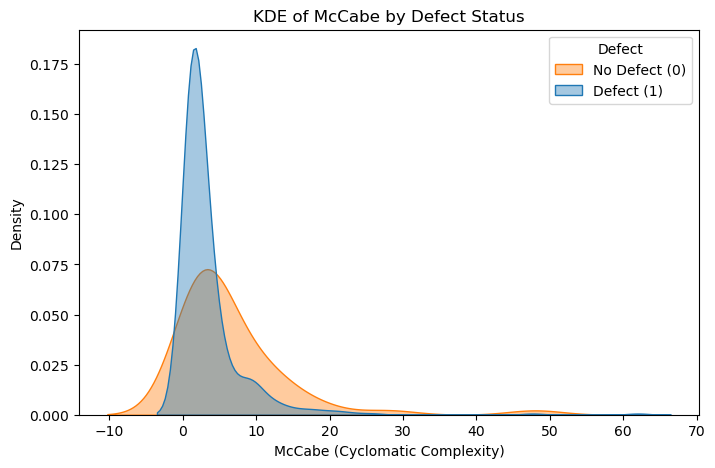

In [37]:
############################################################################################################################################
# 3.a. KDE plot (treatment)
############################################################################################################################################
# Defect modules are slightly shifted toward higher McCabe, but large overlap exists
# Non-defect modules span almost the entire range. This implies:
# McCabe has some effect, but it is not sufficient alone. Confounding (Size) likely matters


plt.figure(figsize=(8, 5))

sns.kdeplot(data=df,
    x=treatment,
    hue=target,
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("KDE of McCabe by Defect Status")
plt.xlabel("McCabe (Cyclomatic Complexity)")
plt.ylabel("Density")
plt.legend(title="Defect", labels=["No Defect (0)", "Defect (1)"])
plt.show()

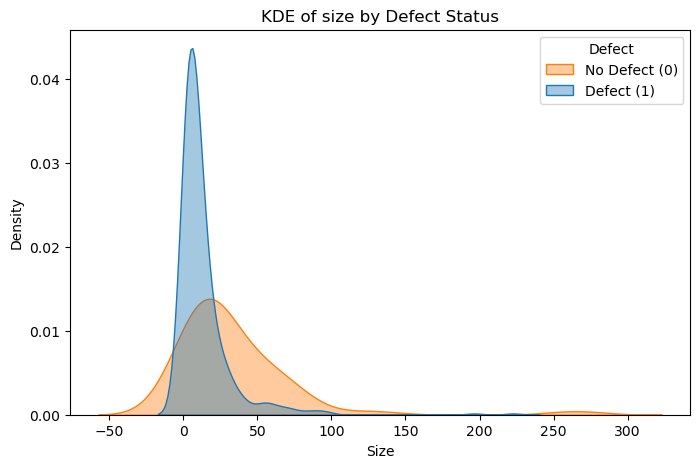

In [39]:
############################################################################################################################################
# 3.b. KDE plot (Size)
############################################################################################################################################

plt.figure(figsize=(8, 5))

sns.kdeplot(data=df,
    x='Size',
    hue=target,
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("KDE of size by Defect Status")
plt.xlabel("Size")
plt.ylabel("Density")
plt.legend(title="Defect", labels=["No Defect (0)", "Defect (1)"])
plt.show()

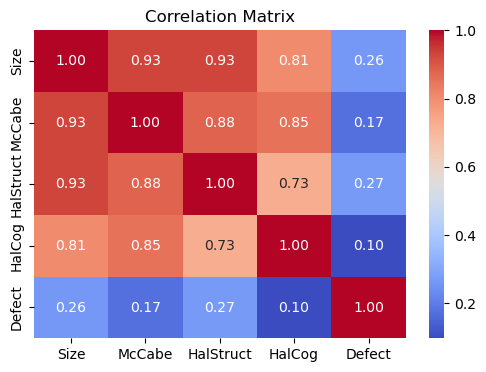

In [43]:
# Plot using seaborn
plt.figure(figsize=(6,4))
cols_not_target = [col for col in df.columns if col != target]

sns.heatmap(df[cols_not_target+[target]].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


<span style="font-size:24px; font-weight:bold;">
Intrinsic causal inference
</span>

Evaluating set functions...: 100%|████████████████████████████████████████████████████| 8/8 [00:00<00:00, 11503.06it/s]


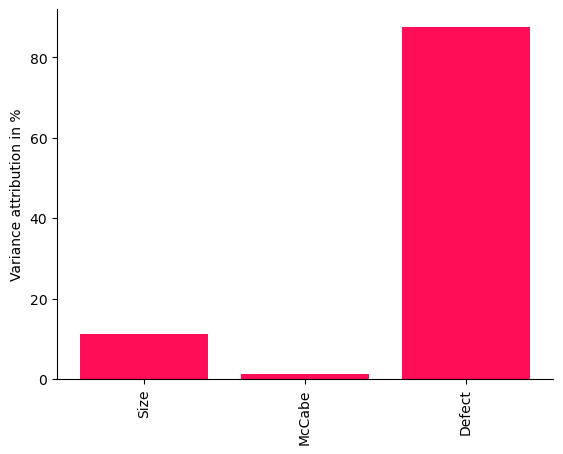

In [79]:
# 1. Create the structural causal model

"""
For the target node: expenses =𝑓(parents,𝑈(expenses))

So there are two sources of variation in expenses:

1. Variation coming through parents (age, smoker, bmi, etc.)

2. Variation coming from its own noise term 𝑈(expenses)

Intrinsic Causal Influence (ICI) explicitly attributes variance to both.
"""

G = nx.DiGraph()
G.add_edges_from([
    ("Size", "McCabe"),
    ("Size", "Defect"),
    ("McCabe", "Defect")
])

causal_model = StructuralCausalModel(G)

# --------------------------------------------------
# Assign Causal Mechanisms
# --------------------------------------------------

# Root node → empirical distribution
causal_model.set_causal_mechanism(
    "Size",
    EmpiricalDistribution()
)

# Continuous child node → additive noise linear model
causal_model.set_causal_mechanism(
    "McCabe",
    AdditiveNoiseModel(create_linear_regressor())
)

# Binary outcome → logistic regression inside additive noise model
causal_model.set_causal_mechanism(
    "Defect",
    AdditiveNoiseModel(create_logistic_regression_classifier())
)

# --------------------------------------------------
# Fit the Structural Model
# --------------------------------------------------

gcm.fit(causal_model, df)

# --------------------------------------------------
# Compute Intrinsic Causal Influence (ICI) and plot
# --------------------------------------------------

from dowhy.gcm import intrinsic_causal_influence

ici = intrinsic_causal_influence(
    causal_model,
    target_node="Defect"
)

# Utility: percentage conversion
def convert_to_percentage(value_dictionary):
    total_absolute_sum = np.sum([abs(v) for v in value_dictionary.values()])
    return {
        k: abs(v) / total_absolute_sum * 100
        for k, v in value_dictionary.items()
    }

bar_plot(
    convert_to_percentage(ici),
    ylabel="Variance attribution in %"
)


In [ ]:
#Software defects may be driven by many factors not in the model, developer skill
#Code reviews, Testing coverage, Requirement ambiguity, Integration complexity, Deadlines, Process maturity, Domain complexity, Team communication
# and Random human error